<a href="https://colab.research.google.com/github/yami-stack/machine_learning/blob/main/Experiments-ML/CSL701_CE48Machine_Learning_Lab_Exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Yash Manohar Tawate Roll No-CE48 Batch-CE03



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [1]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

from google.colab import files

# Upload dataset
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File name:", filename)
print("Dataset shape:", df.shape)

# Display first 5 rows
df.head()

Saving brca.csv to brca.csv
Dataset loaded successfully!
File name: brca.csv
Dataset shape: (569, 32)


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [2]:
# Task 2: Explore the Dataset

# 1. Display dataset dimensions
print("Dataset Dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# 2. Check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# 3. Display summary statistics
print("\nSummary Statistics:")
display(df.describe())

# 4. Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# 5. Check diagnosis class distribution
print("\nDiagnosis Class Distribution:")
print(df["y"].value_counts())

# 6. Display class distribution in percentage
print("\nDiagnosis Class Distribution (%):")
print(df["y"].value_counts(normalize=True) * 100)

Dataset Dimensions:
Rows: 569
Columns: 32

Missing Values in Each Column:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

Summary Statistics:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Column Names:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']

Diagnosis Class Distribution:
y
B    357
M    212
Name: count, dtype: int64

Diagnosis Class Distribution (%):
y
B    62.741652
M    37.258348
Name: proportion, dtype: float64


# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [3]:
# Task 3: Preprocess and Scale Features

# Separate features and target
X = df.drop(columns=["Unnamed: 0", "y"])
y = df["y"]

# Display feature information
print("Feature shape before scaling:", X.shape)
print("Target shape:", y.shape)

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data into DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display scaled data
print("\nFeature shape after scaling:", X_scaled.shape)
print("\nFirst 5 rows after scaling:")
display(X_scaled.head())

Feature shape before scaling: (569, 30)
Target shape: (569,)

Feature shape after scaling: (569, 30)

First 5 rows after scaling:


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,-0.728310,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,0.753087,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250
2,-1.313080,-1.593959,-1.302806,-1.083572,0.429819,-0.747086,-0.743748,-0.726337,0.012345,0.886341,...,-1.250611,-1.631243,-1.254913,-0.994422,0.001377,-0.887193,-0.880434,-0.796903,-0.729224,-0.344455
3,-0.311646,-0.202373,-0.385500,-0.372831,-0.464730,-1.263703,-0.793214,-0.507861,-1.258183,-0.590802,...,-0.614867,-0.466909,-0.679153,-0.588344,-1.549975,-1.323648,-1.073966,-0.981753,-1.478256,-1.233324
4,-1.684571,-0.570050,-1.658278,-1.288347,-0.737294,-0.851130,-0.915500,-1.109197,-0.155598,0.316465,...,-1.512777,-0.605327,-1.489328,-1.122222,-0.116980,-0.754239,-0.975761,-1.354653,0.330422,-0.546168


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [4]:
# Task 4: Construct Pairwise Distance Matrix & Graph

# Compute pairwise Euclidean distances
distance_matrix = squareform(
    pdist(X_scaled, metric="euclidean")
)

# Display distance matrix shape
print("Distance Matrix Shape:", distance_matrix.shape)

# Display first 5 × 5 part of distance matrix
print("\nFirst 5 × 5 Distance Matrix:")
print(distance_matrix[:5, :5])

# Create a weighted complete graph
G = nx.Graph()

# Add 569 samples as nodes
G.add_nodes_from(range(len(X_scaled)))

# Add edges with Euclidean distance as weights
for i in range(len(X_scaled)):
    for j in range(i + 1, len(X_scaled)):
        G.add_edge(i, j, weight=distance_matrix[i, j])

# Display graph information
print("\nWeighted Complete Graph:")
print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

Distance Matrix Shape: (569, 569)

First 5 × 5 Distance Matrix:
[[0.         3.10724668 3.62314178 5.20448164 4.46708561]
 [3.10724668 0.         4.01027585 5.62302017 4.37098277]
 [3.62314178 4.01027585 0.         5.12193591 2.94839575]
 [5.20448164 5.62302017 5.12193591 0.         5.02798792]
 [4.46708561 4.37098277 2.94839575 5.02798792 0.        ]]

Weighted Complete Graph:
Number of Nodes: 569
Number of Edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [5]:
# Task 5: Compute the Minimum Spanning Tree (MST)

# Compute the Minimum Spanning Tree
mst = nx.minimum_spanning_tree(G, weight="weight")

# Display MST information
print("Minimum Spanning Tree (MST)")
print("Number of Nodes:", mst.number_of_nodes())
print("Number of Edges:", mst.number_of_edges())

# Extract MST connections and weights
mst_edges = list(mst.edges(data="weight"))

print("\nFirst 10 MST Edges with Weights:")
for u, v, weight in mst_edges[:10]:
    print(f"Node {u} -- Node {v}, Weight = {weight:.4f}")

# Calculate total MST weight
total_mst_weight = mst.size(weight="weight")

print("\nTotal MST Weight:", total_mst_weight)

Minimum Spanning Tree (MST)
Number of Nodes: 569
Number of Edges: 568

First 10 MST Edges with Weights:
Node 0 -- Node 81, Weight = 1.6886
Node 0 -- Node 108, Weight = 2.1714
Node 1 -- Node 105, Weight = 1.6607
Node 2 -- Node 70, Weight = 2.2189
Node 3 -- Node 170, Weight = 2.3462
Node 3 -- Node 222, Weight = 2.5415
Node 4 -- Node 279, Weight = 1.8603
Node 4 -- Node 84, Weight = 2.1660
Node 5 -- Node 125, Weight = 1.7659
Node 5 -- Node 172, Weight = 2.0171

Total MST Weight: 1393.8520909311528


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [6]:
# Task 6: Implement Graph-Based Clustering (K = 2)

K = 2

# Step 1: Sort MST edges in descending order by weight
sorted_edges = sorted(
    mst.edges(data="weight"),
    key=lambda x: x[2],
    reverse=True
)

# Step 2: Copy the MST
mst_clusters = mst.copy()

# Step 3: Remove the largest K-1 edges
for u, v, weight in sorted_edges[:K-1]:
    mst_clusters.remove_edge(u, v)
    print(f"Removed edge: Node {u} -- Node {v}, Weight = {weight:.4f}")

# Step 4: Find the connected components
components = list(nx.connected_components(mst_clusters))

# Step 5: Assign cluster labels
cluster_labels = np.zeros(len(X_scaled), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

# Display results
print("\nNumber of Clusters:", len(components))

print("\nCluster Sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Removed edge: Node 544 -- Node 553, Weight = 12.2999

Number of Clusters: 2

Cluster Sizes:
0    567
1      2
Name: count, dtype: int64


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [7]:
# Task 7: Evaluate MST Clustering Performance

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Convert ground-truth labels (B/M) into numerical labels
label_encoder = LabelEncoder()
y_true = label_encoder.fit_transform(y)

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, cluster_labels)

# Calculate Adjusted Rand Index (ARI)
ari_score = adjusted_rand_score(y_true, cluster_labels)

# Calculate Normalized Mutual Information (NMI)
nmi_score = normalized_mutual_info_score(y_true, cluster_labels)

# Display results
print("MST Clustering Performance")
print("--------------------------------")
print("Silhouette Score:", sil_score)
print("Adjusted Rand Index (ARI):", ari_score)
print("Normalized Mutual Information (NMI):", nmi_score)

MST Clustering Performance
--------------------------------
Silhouette Score: 0.6606668813897673
Adjusted Rand Index (ARI): 0.0048283446965917305
Normalized Mutual Information (NMI): 0.010182219220269649


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

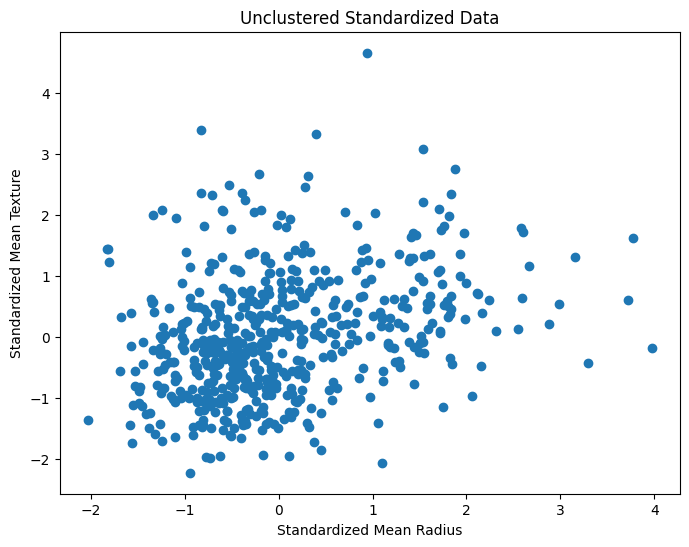

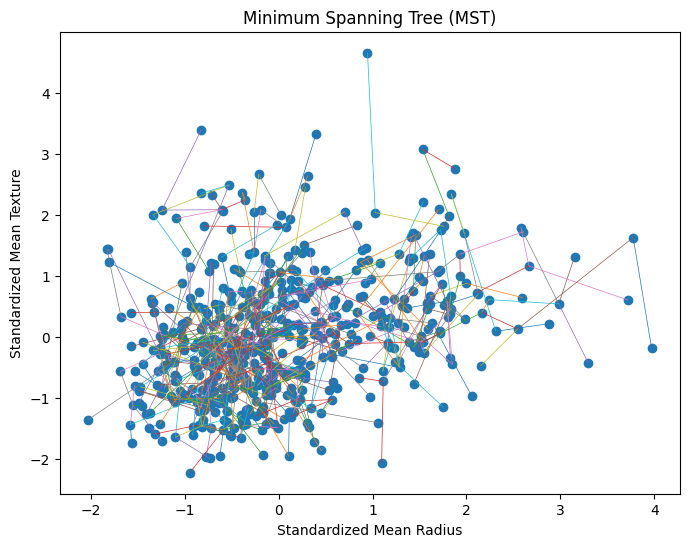

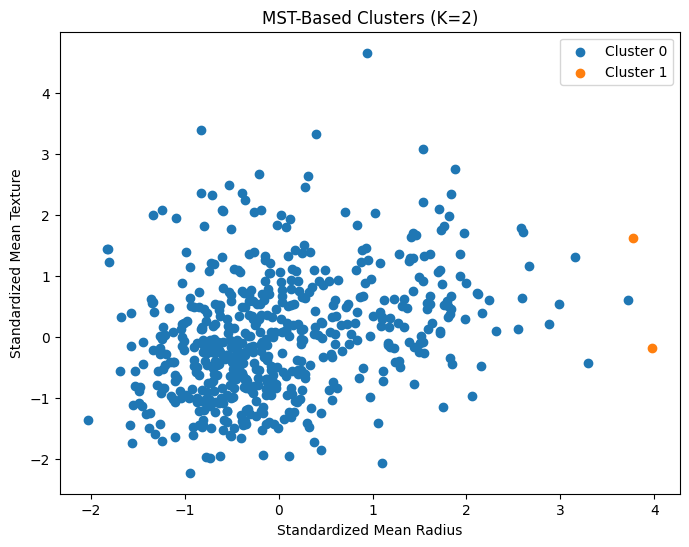

In [8]:
# Task 8: Visualize MST and Graph-Based Clusters

# Select two representative standardized features
x_feature = "x.radius_mean"
y_feature = "x.texture_mean"

x_plot = X_scaled[x_feature].values
y_plot = X_scaled[y_feature].values


# --------------------------------------------------
# Plot 1: Unclustered Standardized Data
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(x_plot, y_plot)

plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.title("Unclustered Standardized Data")

plt.show()


# --------------------------------------------------
# Plot 2: MST Edge Connections
# --------------------------------------------------

plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(x_plot, y_plot)

# Plot MST edges
for u, v in mst.edges():
    plt.plot(
        [x_plot[u], x_plot[v]],
        [y_plot[u], y_plot[v]],
        linewidth=0.5
    )

plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.title("Minimum Spanning Tree (MST)")

plt.show()


# --------------------------------------------------
# Plot 3: Final MST-Based Clusters
# --------------------------------------------------

plt.figure(figsize=(8, 6))

for cluster_id in np.unique(cluster_labels):
    mask = cluster_labels == cluster_id

    plt.scatter(
        x_plot[mask],
        y_plot[mask],
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.title("MST-Based Clusters (K=2)")
plt.legend()

plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.